X_train shape: torch.Size([784, 20, 1])
y_train shape: torch.Size([784, 1])
Model parameters: 50497

Training...
Epoch [20/150], Train Loss: 0.0820, Test Loss: 0.0977
Epoch [40/150], Train Loss: 0.0604, Test Loss: 0.0586
Epoch [60/150], Train Loss: 0.0438, Test Loss: 0.0412
Epoch [80/150], Train Loss: 0.0335, Test Loss: 0.0314
Epoch [100/150], Train Loss: 0.0334, Test Loss: 0.0314
Epoch [120/150], Train Loss: 0.0318, Test Loss: 0.0310
Epoch [140/150], Train Loss: 0.0317, Test Loss: 0.0311


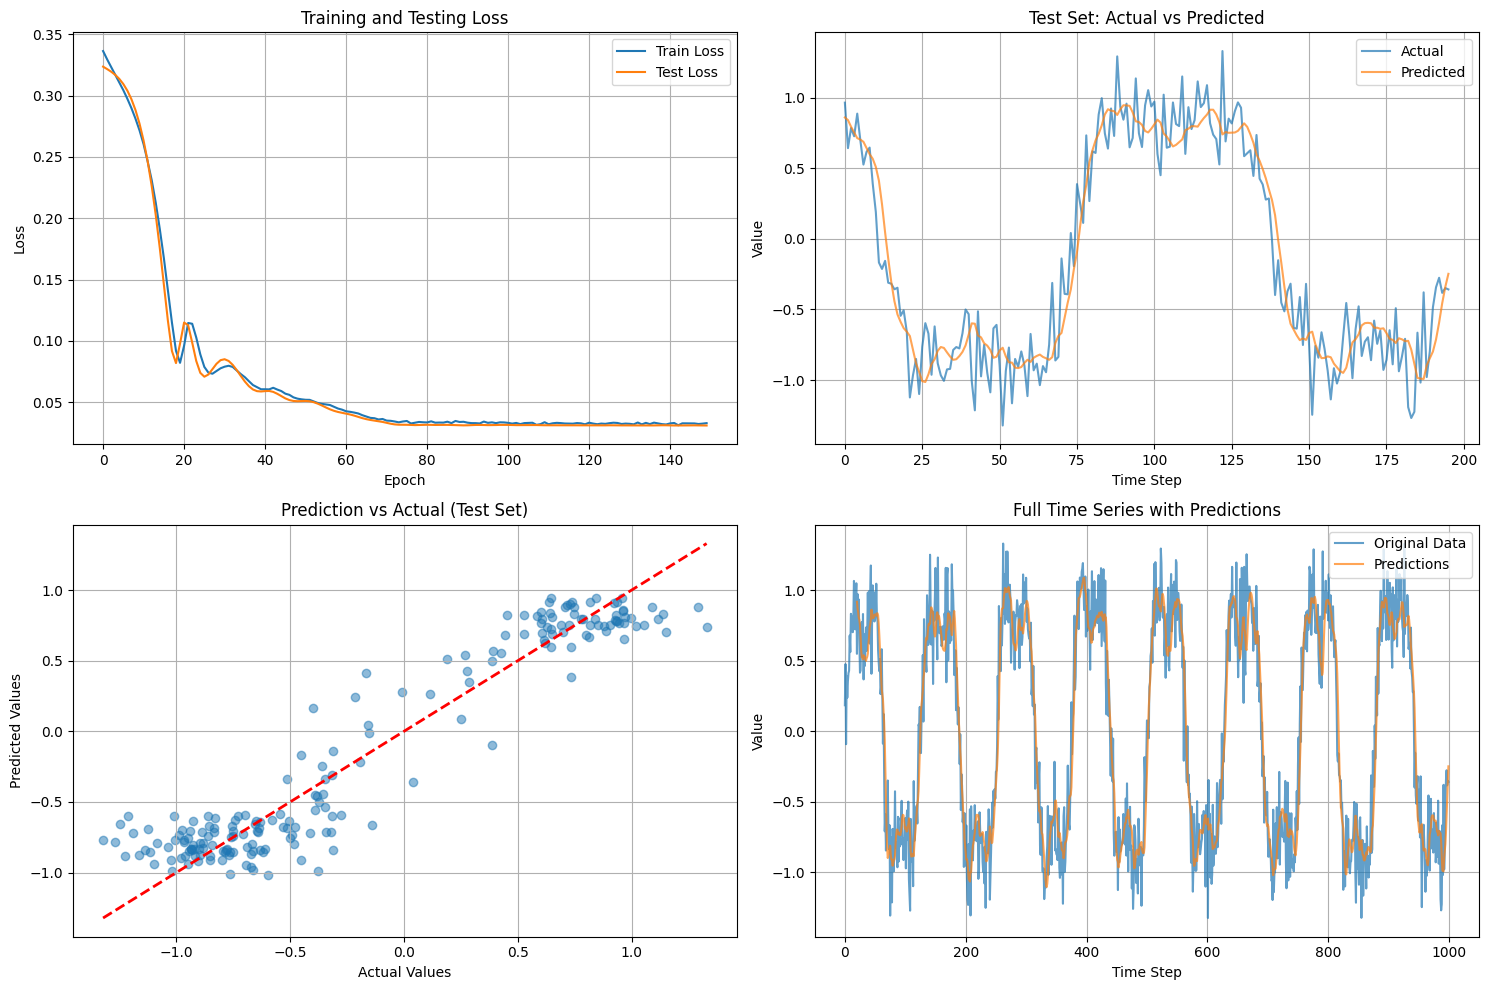

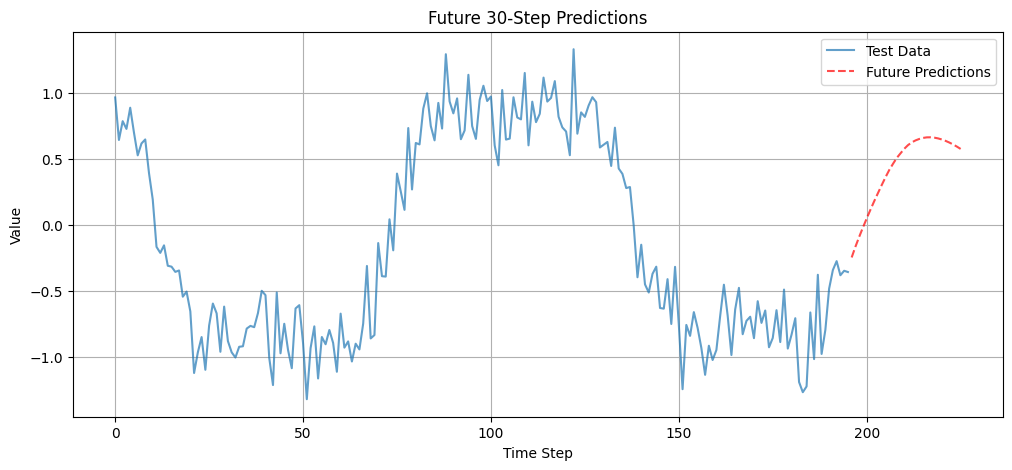


MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): 0.1848
Mean Squared Error (MSE): 0.0544
Root Mean Squared Error (RMSE): 0.2332
R² Score: 0.9048


In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ======================
# 1. Generate Synthetic Time Series Data
# ======================
def generate_time_series(n_steps=1000):
    time = np.linspace(0, 50, n_steps)
    series = np.sin(time) + 0.3 * np.sin(3 * time) + 0.2 * np.random.randn(n_steps)
    return series.reshape(-1, 1)

# Create dataset
data = generate_time_series(1000)

# Normalize data
scaler = MinMaxScaler(feature_range=(-1, 1))
data_normalized = scaler.fit_transform(data)

# ======================
# 2. Create Sequences
# ======================
def create_sequences(data, seq_length=20):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 20
X, y = create_sequences(data_normalized, SEQ_LENGTH)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print(f"X_train shape: {X_train.shape}")  # (samples, seq_length, 1)
print(f"y_train shape: {y_train.shape}")  # (samples, 1)

# ======================
# 3. Define LSTM Model
# ======================
class TimeSeriesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(TimeSeriesLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Initialize model
model = TimeSeriesLSTM(input_size=1, hidden_size=64, num_layers=2, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

# ======================
# 4. Training Loop
# ======================
def train_model(model, X_train, y_train, X_test, y_test, epochs=100):
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()

        train_outputs = model(X_train)
        train_loss = criterion(train_outputs, y_train)

        train_loss.backward()
        optimizer.step()

        # Testing
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

    return train_losses, test_losses

# Train the model
print("\nTraining...")
train_losses, test_losses = train_model(model, X_train, y_train, X_test, y_test, epochs=150)

# ======================
# 5. Make Predictions
# ======================
model.eval()
with torch.no_grad():
    train_predictions = model(X_train).numpy()
    test_predictions = model(X_test).numpy()

# Inverse transform to original scale
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)
y_train_actual = scaler.inverse_transform(y_train.numpy())
y_test_actual = scaler.inverse_transform(y_test.numpy())

# ======================
# 6. Visualization
# ======================
plt.figure(figsize=(15, 10))

# Plot 1: Training loss
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()
plt.grid(True)

# Plot 2: Actual vs Predicted (Test set)
plt.subplot(2, 2, 2)
plt.plot(y_test_actual, label='Actual', alpha=0.7)
plt.plot(test_predictions, label='Predicted', alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('Test Set: Actual vs Predicted')
plt.legend()
plt.grid(True)

# Plot 3: Scatter plot of predictions
plt.subplot(2, 2, 3)
plt.scatter(y_test_actual, test_predictions, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Prediction vs Actual (Test Set)')
plt.grid(True)

# Plot 4: Full time series with predictions
plt.subplot(2, 2, 4)
full_predictions = np.concatenate([train_predictions, test_predictions])
plt.plot(scaler.inverse_transform(data_normalized), label='Original Data', alpha=0.7)
plt.plot(range(SEQ_LENGTH, SEQ_LENGTH + len(full_predictions)),
         full_predictions, label='Predictions', alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('Full Time Series with Predictions')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ======================
# 7. Future Prediction Function
# ======================
def predict_future(model, last_sequence, n_steps=10):
    """
    Predict future values recursively
    """
    model.eval()
    current_sequence = last_sequence.clone().detach().float()
    predictions = []

    with torch.no_grad():
        for _ in range(n_steps):
            # Predict next value
            next_pred = model(current_sequence.unsqueeze(0))
            predictions.append(next_pred.item())

            # Update sequence (remove first, add prediction)
            current_sequence = torch.cat([
                current_sequence[1:],
                torch.FloatTensor([[next_pred.item()]])
            ])

    return np.array(predictions).reshape(-1, 1)

# Get last sequence from test data
last_sequence = X_test[-1]

# Predict next 30 values
future_steps = 30
future_predictions = predict_future(model, last_sequence, future_steps)
future_predictions = scaler.inverse_transform(future_predictions)

# Plot future predictions
plt.figure(figsize=(12, 5))
plt.plot(range(len(y_test_actual)), y_test_actual, label='Test Data', alpha=0.7)
plt.plot(range(len(y_test_actual), len(y_test_actual) + future_steps),
         future_predictions, 'r--', label='Future Predictions', alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title(f'Future {future_steps}-Step Predictions')
plt.legend()
plt.grid(True)
plt.show()

# ======================
# 8. Evaluation Metrics
# ======================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics for test set
mae = mean_absolute_error(y_test_actual, test_predictions)
mse = mean_squared_error(y_test_actual, test_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, test_predictions)

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print("="*50)

# ======================
# 9. Save Model (Optional)
# ======================
# torch.save(model.state_dict(), 'timeseries_lstm.pth')
# print("\nModel saved as 'timeseries_lstm.pth'")